# Пайплайн аугментации

Ноутбук последовательно:
1. Разбивает данные на **train/test** (80/20, стратифицированно)
2. Аугментирует **только train** через 3 этапа
3. Оценивает baseline-классификаторы **на test**

**Этапы аугментации:**
1. LLM-генерация (< 15 → 15)
2. Парафраз через LLM (< 35 → 35)
3. Обратный перевод (< 50 → 50)

**Классификация (baseline):**
- Linear SVM (TF-IDF)
- Logistic Regression (TF-IDF)
- Multinomial Naive Bayes (TF-IDF)
- rubert-tiny2 (fine-tuning)

___
## Подготовка окружения (Запуск в Colab)

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path

REPO_URL = 'https://github.com/KVTur23/llm-finetuning-text-classification.git'
REPO_BRANCH = 're-augmentation'
REPO_DIR = Path('/content/VKR')
PROJECT_ROOT = REPO_DIR / 'code'

DRIVE_ROOT = Path('/content/drive/MyDrive/VKR')
DRIVE_DATA = DRIVE_ROOT / 'Data'
DRIVE_RESULTS = DRIVE_ROOT / 'results'


In [3]:
import shutil
import subprocess

if (REPO_DIR / '.git').exists():
    print('Репо уже клонирован — обновляю из origin')
    subprocess.run(['git', '-C', str(REPO_DIR), 'fetch', 'origin'], check=True)
    subprocess.run(['git', '-C', str(REPO_DIR), 'checkout', '-B', REPO_BRANCH, f'origin/{REPO_BRANCH}'], check=True)
else:
    print(f'Клонирую {REPO_URL} в {REPO_DIR}')
    subprocess.run(['git', 'clone', '-b', REPO_BRANCH, REPO_URL, str(REPO_DIR)], check=True)

def link_to_drive(name, drive_path):
    local_path = PROJECT_ROOT / name
    drive_path.parent.mkdir(parents=True, exist_ok=True)

    drive_missing_or_empty = not drive_path.exists() or not any(drive_path.iterdir())
    if drive_missing_or_empty:
        if local_path.exists() and not local_path.is_symlink():
            if drive_path.exists():
                shutil.rmtree(drive_path)
            shutil.copytree(local_path, drive_path)
        else:
            drive_path.mkdir(parents=True, exist_ok=True)

    if local_path.is_symlink() or local_path.is_file():
        local_path.unlink()
    elif local_path.exists():
        shutil.rmtree(local_path)

    local_path.symlink_to(drive_path, target_is_directory=True)
    print(f'{name}: {local_path} -> {drive_path}')

link_to_drive('Data', DRIVE_DATA)
link_to_drive('results', DRIVE_RESULTS)


commit = subprocess.run(
    ['git', '-C', str(REPO_DIR), 'log', '-1', '--oneline'],
    capture_output=True, text=True, check=True,
).stdout.strip()
print(f'\nТекущий коммит: {commit}')


Репо уже клонирован — обновляю из origin
Data: /content/VKR/code/Data -> /content/drive/MyDrive/VKR/Data
results: /content/VKR/code/results -> /content/drive/MyDrive/VKR/results

Текущий коммит: ffe112f Validate finetune model cache weights


In [4]:
import sys
import pandas as pd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%cd {PROJECT_ROOT}

from src.utils.data_loader import (
    load_dataset, get_class_distribution, split_train_test, load_test_set,
    LABEL_COL, RANDOM_SEED, DATA_DIR, ORIGINAL_FILE,
)

print(f'Корень проекта: {PROJECT_ROOT}')
print(f'Папка данных:   {DATA_DIR}')
print(f'Drive Data:     {DRIVE_DATA}')

from src.utils.pipeline_config import load_pipeline_config

# === GPU ПРОФИЛЬ — МЕНЯЙ ЗДЕСЬ ===
GPU = 'A100_40'  # варианты: 'T4', 'L4', 'A100_40', 'A100_80', 'H100'
pipeline_cfg = load_pipeline_config(GPU)


/content/VKR/code
Корень проекта: /content/VKR/code
Папка данных:   /content/VKR/code/Data
Drive Data:     /content/drive/MyDrive/VKR/Data
[Config] GPU: A100_40 (40GB), NLLB: facebook/nllb-200-3.3B, batch: 64


## Подготовка окружения (Локальный запуск)

In [5]:
# import sys
# from pathlib import Path
# import pandas as pd

# PROJECT_ROOT = Path("/Users/kvt/Documents/VKR/code")         

# # Добавляем корень в sys.path
# if str(PROJECT_ROOT) not in sys.path:
#     sys.path.insert(0, str(PROJECT_ROOT))

# %cd {PROJECT_ROOT}

# from src.utils.data_loader import (
#     load_dataset, get_class_distribution, split_train_test, load_test_set,
#     LABEL_COL, RANDOM_SEED, DATA_DIR, ORIGINAL_FILE,
# )

# print(f"Корень проекта: {PROJECT_ROOT}")
# print(f"Папка данных:   {DATA_DIR}")

# from src.utils.pipeline_config import load_pipeline_config

# # === GPU ПРОФИЛЬ — МЕНЯЙ ЗДЕСЬ ===
# GPU = "A100_40"  # варианты: "T4", "L4", "A100_40", "A100_80", "H100"
# pipeline_cfg = load_pipeline_config(GPU)

In [6]:
# Ставим зависимости из requirements.txt
!pip install -q -r {PROJECT_ROOT}/requirements.txt

___
## Предобработка данных

Очистка сырых данных: удаление дубликатов, повторов слов, циклов, обрезка приложений.

`data.json` → `data_after_eda.csv`

In [7]:
from src.utils.data_cleaner import run as run_cleaning

eda_path = DATA_DIR / "data_after_eda.csv"

if eda_path.exists():
    print(f"data_after_eda.csv уже существует ({len(pd.read_csv(eda_path))} записей), пропускаем")
else:
    run_cleaning()

data_after_eda.csv уже существует (1750 записей), пропускаем


___
## Разделение на train / test

Стратифицированное разбиение 80/20 с гарантией минимум 1 примера на класс в каждой части.
Аугментация применяется **только к train**. Оценка — **на test**.

In [8]:
from src.utils.data_loader import STAGE_FILES, TEST_FILE

train_path = DATA_DIR / STAGE_FILES[0]  # train_after_eda.csv
test_path = DATA_DIR / TEST_FILE         # data_test.csv

if train_path.exists() and test_path.exists():
    # Уже разбито — просто загружаем
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    print(f"Train/test уже существуют, загружены из файлов")
else:
    # Первый запуск — разбиваем оригинал
    original_path = DATA_DIR / ORIGINAL_FILE
    df_original = pd.read_csv(original_path)
    print(f"Загружен оригинал: {original_path.name} ({len(df_original)} записей)")
    df_train, df_test = split_train_test(df_original)

print(f"\nTrain: {len(df_train)} ({len(df_train)/(len(df_train)+len(df_test))*100:.0f}%)")
print(f"Test:  {len(df_test)} ({len(df_test)/(len(df_train)+len(df_test))*100:.0f}%)")

Train/test уже существуют, загружены из файлов

Train: 1409 (81%)
Test:  341 (19%)


In [9]:
# Распределение по классам в train и test
dist_train = get_class_distribution(df_train)
dist_test = get_class_distribution(df_test)

print(f"{'Класс':<70} {'Train':>6} {'Test':>5}")
print("-" * 85)
for cls in dist_train.index:
    tr = dist_train[cls]
    te = dist_test.get(cls, 0)
    print(f"  {cls:<68} {tr:>6} {te:>5}")
print("-" * 85)
print(f"  {'ИТОГО':<68} {len(df_train):>6} {len(df_test):>5}")

Класс                                                                   Train  Test
-------------------------------------------------------------------------------------
  Блок технического директора                                             197    49
  Блок директора по мощностям                                             193    48
  Блок директора по строительству                                         131    32
  Управление по проектным работам                                         108    27
  Блок заместителя генерального директора по безопасности                  99    24
  Генеральный директор                                                     82    20
  Проект "Нефтяные краюшки"                                                64    15
  Блок деректора по газу                                                   57    14
  Блок заместителя генерального директора по закупкам                      54    13
  Блок заместителя генерального директора по организационным вопросам     

___
## Baseline — классификация ДО аугментации

Обучаем те же модели на **оригинальном train** (без аугментации), 
чтобы потом сравнить с результатами после аугментации.

In [ ]:
from src.classification.evaluate import load_data, evaluate_model
from src.classification.embeddings import prepare_features
from sklearn.preprocessing import LabelEncoder

# Загружаем оригинальный train (stage=0) и test
df_train_orig = load_dataset(stage=0)
df_test_baseline = load_test_set()

X_train_orig, y_train_orig_raw, X_test_orig, y_test_orig_raw = prepare_features(
    df_train_orig, df_test_baseline
)

le_baseline = LabelEncoder()
y_train_orig = le_baseline.fit_transform(y_train_orig_raw)
y_test_orig = le_baseline.transform(y_test_orig_raw)
label_names_baseline = le_baseline.classes_

print(f"Train (без аугментации): {X_train_orig.shape}")
print(f"Test: {X_test_orig.shape}")
print(f"Классов: {len(label_names_baseline)}")

In [11]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

baseline_results = []

print("=" * 60)
print("BASELINE (без аугментации)")
print("=" * 60)

baseline_results.append(evaluate_model(
    name="[Baseline] Linear SVM",
    estimator=LinearSVC(max_iter=10000, random_state=RANDOM_SEED, dual="auto"),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

baseline_results.append(evaluate_model(
    name="[Baseline] Logistic Regression",
    estimator=LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

baseline_results.append(evaluate_model(
    name="[Baseline] Multinomial Naive Bayes",
    estimator=MultinomialNB(),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"alpha": [0.01, 0.1, 0.5, 1.0]},
))

BASELINE (без аугментации)
КЛАССИФИКАЦИЯ: [Baseline] Linear SVM
[[Baseline] Linear SVM] Train: 1409, Test: 341, Классов: 36


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[[Baseline] Linear SVM] Лучшие параметры: {'C': 1} (CV macro F1 = 0.4682)

[[Baseline] Linear SVM] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4208
  Macro F1:          0.4434

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.00      0.00      0.00         1
                                                      Блок деректора по газу       0.78      0.50      0.61        14
                                          Блок директора по газовым проектам       0.50      0.17      0.25         6
                                                 Блок директора по мощностям       0.69      0.94      0.80        48
                                                 Блок директора по персоналу       1.00      0.67      0.80         3
                                                  Блок директора по портфелю       0.00      0.00      

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[[Baseline] Logistic Regression] Лучшие параметры: {'C': 10} (CV macro F1 = 0.3717)

[[Baseline] Logistic Regression] Результаты на тестовой выборке:
  Balanced Accuracy: 0.3089
  Macro F1:          0.3350

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.00      0.00      0.00         1
                                                      Блок деректора по газу       0.75      0.21      0.33        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.65      0.94      0.77        48
                                                 Блок директора по персоналу       0.00      0.00      0.00         3
                                                  Блок директора по портфелю       0

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[[Baseline] Multinomial Naive Bayes] Лучшие параметры: {'alpha': 0.01} (CV macro F1 = 0.4461)

[[Baseline] Multinomial Naive Bayes] Результаты на тестовой выборке:
  Balanced Accuracy: 0.3849
  Macro F1:          0.4026

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.00      0.00      0.00         1
                                                      Блок деректора по газу       0.75      0.43      0.55        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.70      0.96      0.81        48
                                                 Блок директора по персоналу       1.00      0.67      0.80         3
                                                  Блок директора по по

In [12]:
from src.classification.rubert_classifier import train_and_evaluate

# --- Настройки моделей ---
RUBERT_CONFIGS = [
    {
        "model_name": "cointegrated/rubert-tiny2",
        "short_name": "rubert-tiny2",
        "lr": 5e-4,
        "num_epochs": 15,
        "batch_size": 32,
    },
    {
        "model_name": "DeepPavlov/rubert-base-cased",
        "short_name": "rubert-base",
        "lr": 5e-5,
        "num_epochs": 15,
        "batch_size": 32,
    },
]

for cfg in RUBERT_CONFIGS:
    baseline_results.append(train_and_evaluate(
        df_train=df_train_orig,
        df_test=df_test_baseline,
        model_name=cfg["model_name"],
        lr=cfg["lr"],
        num_epochs=cfg["num_epochs"],
        batch_size=cfg["batch_size"],
        name=f"[Baseline] {cfg['short_name']}",
    ))


[[Baseline] rubert-tiny2] Device: cuda, Model: cointegrated/rubert-tiny2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  Epoch 11/15 — loss: 0.2599


  Epoch 12/15 — loss: 0.2277


  Epoch 13/15 — loss: 0.1695


  Epoch 14/15 — loss: 0.1479


  Epoch 15/15 — loss: 0.1340

[[Baseline] rubert-base] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4343
  Macro F1:          0.4198

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.54      0.50      0.52        14
                                          Блок директора по газовым проектам       0.50      0.17      0.25         6
                                                 Блок директора по мощностям       0.80      0.90      0.84        48
                                                 Блок директора по персоналу       0.50      1.00      0.67         3
                                                  Блок директора по портфелю       0.00      0.00      0.00         4
                             

___
## Этап 1: LLM-генерация (< 15 -> 15)

Классы с менее чем 15 примерами дополняются новыми текстами,
сгенерированными через LLM.

In [13]:
# Путь до конфига модели 
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_qwen.json")
# урезанная
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_qwen_3b.json")
# квантизированная
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_qwen_14b_unsloth.json")
# print(f"Конфиг модели: {CONFIG_PATH}")
# AWQ квантизиция
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_vllm.json")
# print(f"Конфиг модели: {CONFIG_PATH}")

# # Если есть мощность A100 и лучше
CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_vllm_32b.json")
print(f"Конфиг модели: {CONFIG_PATH}")

Конфиг модели: /content/VKR/code/config_models/aug_configs/model_vllm_32b.json


In [14]:
from src.augmentation.stage1_llm_generate import run as run_stage1

run_stage1(CONFIG_PATH, pipeline_cfg=pipeline_cfg)

ЭТАП 1: LLM-генерация (< 15 → 15)
[Данные] Найден чекпоинт этапа 1: data_after_stage1.csv (1533 записей)
[Этап 1] Все классы уже имеют >= 15 примеров, этап пропущен
[Данные] Сохранён чекпоинт этапа 1: data_after_stage1.csv (1533 записей)


In [15]:
df_after_s1 = load_dataset(stage=1)
dist_s1 = get_class_distribution(df_after_s1)
while (dist_s1 < 15).sum() != 0:# Проверяем результат после этапа 1
    print(f"Записей после этапа 1: {len(df_after_s1)}")
    print(f"Классов с < 15 примерами: {(dist_s1 < 15).sum()}")
    print(f"{"="*100}\n\n")
    print("Повторяем 1й этап")
    print(f"\n\n{"="*100}")
    run_stage1(CONFIG_PATH, pipeline_cfg=pipeline_cfg)
    df_after_s1 = load_dataset(stage=1)
    dist_s1 = get_class_distribution(df_after_s1)
print("Этап 1: Генерация с помощью LLM полностью завершен.")

[Данные] Найден чекпоинт этапа 1: data_after_stage1.csv (1533 записей)
Этап 1: Генерация с помощью LLM полностью завершен.


## 3. Этап 2: Парафраз через LLM (< 35 -> 35)

Классы с менее чем 35 примерами пополняются через перефразирование
существующих текстов — LLM получает оригинал и переписывает его
другими словами, сохраняя смысл.

In [16]:
from src.augmentation.stage2_paraphrase import run as run_stage2

run_stage2(CONFIG_PATH, pipeline_cfg=pipeline_cfg)

ЭТАП 2: Парафраз через LLM (< 35 → 35)
       источник парафраза: ТОЛЬКО ОРИГИНАЛЫ (stage 0)
[Данные] Найден чекпоинт этапа 2: data_after_stage2.csv (1941 записей)
[Этап 2] Все классы уже имеют >= 35 примеров, этап пропущен
[Данные] Сохранён чекпоинт этапа 2: data_after_stage2.csv (1941 записей)


In [17]:
# Проверяем результат после этапа 2
df_after_s2 = load_dataset(stage=2)
dist_s2 = get_class_distribution(df_after_s2)

print(f"Записей после этапа 2: {len(df_after_s2)}")
print(f"Классов с < 35 примерами: {(dist_s2 < 35).sum()}")

[Данные] Найден чекпоинт этапа 2: data_after_stage2.csv (1941 записей)
Записей после этапа 2: 1941
Классов с < 35 примерами: 0


## 4. Этап 3: Обратный перевод (< 50 -> 50)

Оставшиеся классы с менее чем 50 примерами дополняются через
обратный перевод RU → EN → RU (facebook/nllb-200-distilled-600M).

In [18]:
from src.augmentation.stage3_back_translation import run as run_stage3

run_stage3(CONFIG_PATH, pipeline_cfg=pipeline_cfg)

ЭТАП 3: Обратный перевод (< 50 → 50)
       источник BT: ТОЛЬКО ОРИГИНАЛЫ (stage 0)
[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2331 записей)
[Этап 3] Чекпоинт неполный, 1 классов < 50 — доаугментируем

[Этап 3] Классов для аугментации: 1
  «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: 46 → нужно ещё 4
[Данные] Найден чекпоинт этапа 0: train_after_eda.csv (1409 записей)

[Этап 3] Круг 1/2, pivot 1/3: eng_Latn, cosine_threshold=0.95
  «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: 46 → нужно ещё 4
[Перевод] Загружаю NLLB-200: facebook/nllb-200-3.3B (устройство: cuda)


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

pytorch_model-00001-of-00003.bin:   0%|          | 0.00/6.93G [00:00<?, ?B/s]

pytorch_model-00002-of-00003.bin:   0%|          | 0.00/8.55G [00:00<?, ?B/s]

pytorch_model-00003-of-00003.bin:   0%|          | 0.00/2.10G [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

KeyboardInterrupt: 

In [19]:
# Проверяем финальный результат
df_final = load_dataset(stage=3)
dist_final = get_class_distribution(df_final)

print(f"Записей после всех этапов: {len(df_final)}")
print(f"Классов с < 50 примерами: {(dist_final < 50).sum()}")
print(f"\nМинимум примеров в классе: {dist_final.min()}")
print(f"Максимум примеров в классе: {dist_final.max()}")

[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2331 записей)
Записей после всех этапов: 2331
Классов с < 50 примерами: 1

Минимум примеров в классе: 46
Максимум примеров в классе: 197


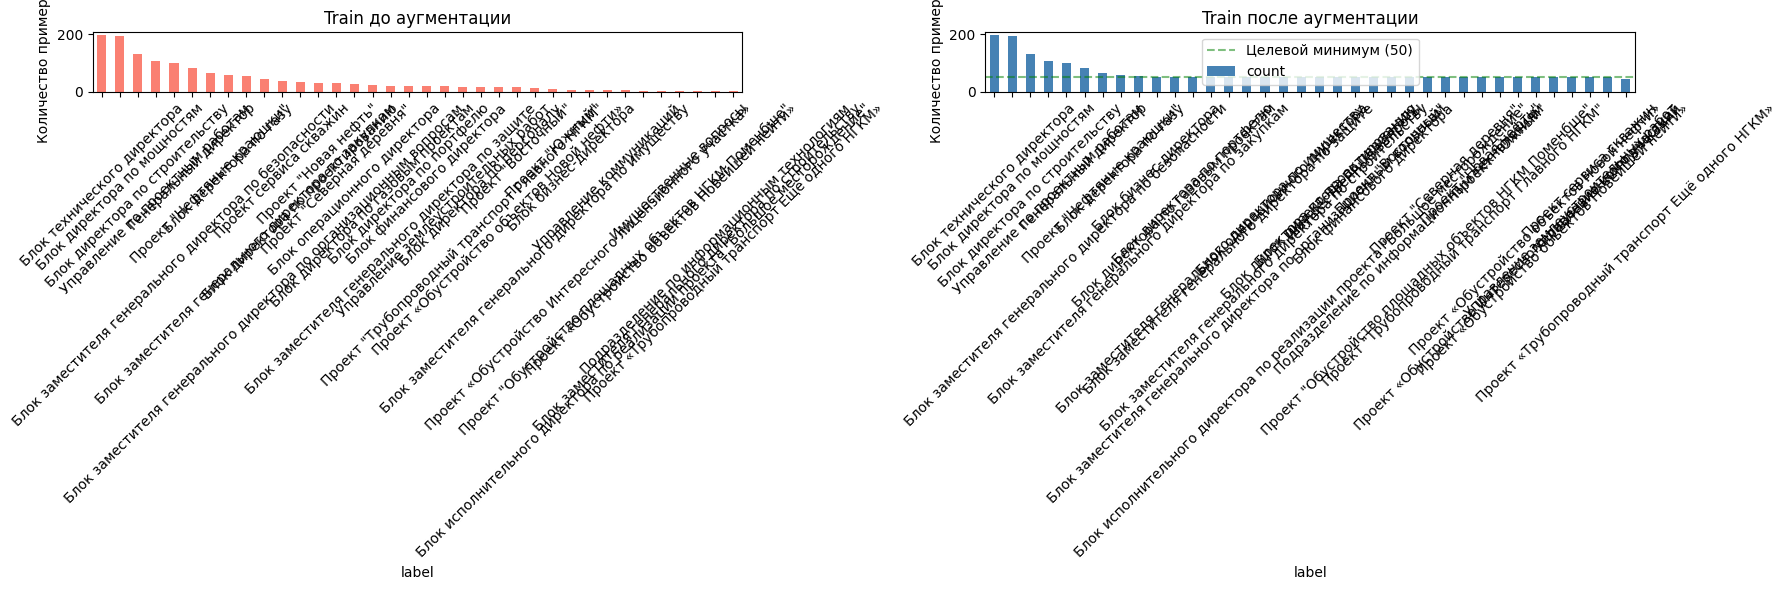

In [21]:
import matplotlib.pyplot as plt

# Сравниваем распределение: train до и после аугментации
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dist_train.plot(kind="bar", ax=axes[0], color="salmon")
axes[0].set_title("Train до аугментации")
axes[0].set_ylabel("Количество примеров")
axes[0].tick_params(axis="x", rotation=45)

dist_final.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Train после аугментации")
axes[1].set_ylabel("Количество примеров")
axes[1].axhline(y=50, color="g", linestyle="--", alpha=0.5, label="Целевой минимум (50)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

___
## Классификация — оценка качества аугментации

Обучаем на аугментированном train, оцениваем на отложенном test.
Данные загружаются один раз, все модели используют одни и те же эмбеддинги.

### Загрузка данных и эмбеддингов

In [22]:
from src.classification.evaluate import load_data, evaluate_model

X_train, y_train, X_test, y_test, label_names = load_data()

print(f"Train: {X_train.shape}, Test: {X_test.shape}, Классов: {len(label_names)}")

[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2331 записей)
[Данные] Тестовая выборка: data_test.csv (341 записей)
[TF-IDF] Параметры: max_features=50000, ngram_range=(1, 2)
[TF-IDF] Обучаю на 2331 текстах...
[TF-IDF] Готово: train (2331, 43616), test (341, 43616)
[TF-IDF] Кэш сохранён (ключ: 3a86a150eb53)
Train: (2331, 43616), Test: (341, 43616), Классов: 36


### Linear SVM

In [23]:
from sklearn.svm import LinearSVC

augmented_results = []

augmented_results.append(evaluate_model(
    name="[Augmented] Linear SVM",
    estimator=LinearSVC(max_iter=10000, random_state=RANDOM_SEED, dual="auto"),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

КЛАССИФИКАЦИЯ: [Augmented] Linear SVM
[[Augmented] Linear SVM] Train: 2331, Test: 341, Классов: 36
[[Augmented] Linear SVM] Лучшие параметры: {'C': 10} (CV macro F1 = 0.8321)

[[Augmented] Linear SVM] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4905
  Macro F1:          0.4785

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.62      0.57      0.59        14
                                          Блок директора по газовым проектам       0.50      0.17      0.25         6
                                                 Блок директора по мощностям       0.75      0.94      0.83        48
                                                 Блок директора по персоналу       1.00      0.67      0.80         3
 

### Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

augmented_results.append(evaluate_model(
    name="[Augmented] Logistic Regression",
    estimator=LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

КЛАССИФИКАЦИЯ: [Augmented] Logistic Regression
[[Augmented] Logistic Regression] Train: 2331, Test: 341, Классов: 36
[[Augmented] Logistic Regression] Лучшие параметры: {'C': 10} (CV macro F1 = 0.7952)

[[Augmented] Logistic Regression] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4501
  Macro F1:          0.4599

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       1.00      0.29      0.44        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.70      0.94      0.80        48
                                                 Блок директора по персоналу       

### Multinomial Naive Bayes

In [25]:
from sklearn.naive_bayes import MultinomialNB

augmented_results.append(evaluate_model(
    name="[Augmented] Multinomial Naive Bayes",
    estimator=MultinomialNB(),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"alpha": [0.01, 0.1, 0.5, 1.0]},
))

КЛАССИФИКАЦИЯ: [Augmented] Multinomial Naive Bayes
[[Augmented] Multinomial Naive Bayes] Train: 2331, Test: 341, Классов: 36
[[Augmented] Multinomial Naive Bayes] Лучшие параметры: {'alpha': 0.01} (CV macro F1 = 0.8138)

[[Augmented] Multinomial Naive Bayes] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4781
  Macro F1:          0.4826

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.70      0.50      0.58        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.69      0.98      0.81        48
                                                 Блок директо

### BERT-модели (fine-tuning)


In [26]:
from src.classification.rubert_classifier import train_and_evaluate

# --- Настройки моделей ---
RUBERT_CONFIGS = [
    {
        "model_name": "cointegrated/rubert-tiny2",
        "short_name": "rubert-tiny2",
        "lr": 5e-4,
        "num_epochs": 10,
        "batch_size": 32,
    },
    {
        "model_name": "DeepPavlov/rubert-base-cased",
        "short_name": "rubert-base",
        "lr": 5e-5,
        "num_epochs": 14,
        "batch_size": 32,
    },
]

# df_final уже загружен выше (stage=3), df_test_baseline тоже
for cfg in RUBERT_CONFIGS:
    augmented_results.append(train_and_evaluate(
        df_train=df_final,
        df_test=df_test_baseline,
        model_name=cfg["model_name"],
        lr=cfg["lr"],
        num_epochs=cfg["num_epochs"],
        batch_size=cfg["batch_size"],
        name=f"[Augmented] {cfg['short_name']}",
    ))

[[Augmented] rubert-tiny2] Device: cuda, Model: cointegrated/rubert-tiny2


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[[Augmented] rubert-tiny2] Train: 2331, Test: 341, Классов: 36, Эпох: 10


  Epoch 1/10 — loss: 3.3783


  Epoch 2/10 — loss: 2.2080


...

  Epoch 6/10 — loss: 0.3670


  Epoch 7/10 — loss: 0.2257


  Epoch 8/10 — loss: 0.1507


  Epoch 9/10 — loss: 0.0971


  Epoch 10/10 — loss: 0.0745

[[Augmented] rubert-base] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4921
  Macro F1:          0.4291

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.50      0.50      0.50        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.77      0.85      0.81        48
                                                 Блок директора по персоналу       0.43      1.00      0.60         3
                                                  Блок директора по портфелю       0.00      0.00      0.00         4
                            

___
## Сравнение: Baseline vs Augmented

Сводная таблица и график — как изменились метрики после аугментации для каждого классификатора.

Модель                    | Метрика              |   Baseline |  Augmented |      Delta
-----------------------------------------------------------------------------------
  Linear SVM              | Balanced Accuracy    |     0.4208 |     0.4905 | +   0.0697
  Linear SVM              | Macro F1             |     0.4434 |     0.4785 | +   0.0351
-----------------------------------------------------------------------------------
  Logistic Regression     | Balanced Accuracy    |     0.3089 |     0.4501 | +   0.1412
  Logistic Regression     | Macro F1             |     0.3350 |     0.4599 | +   0.1249
-----------------------------------------------------------------------------------
  Multinomial Naive Bayes | Balanced Accuracy    |     0.3849 |     0.4781 | +   0.0932
  Multinomial Naive Bayes | Macro F1             |     0.4026 |     0.4826 | +   0.0801
-----------------------------------------------------------------------------------
  rubert-tiny2            | Balanced Accuracy   

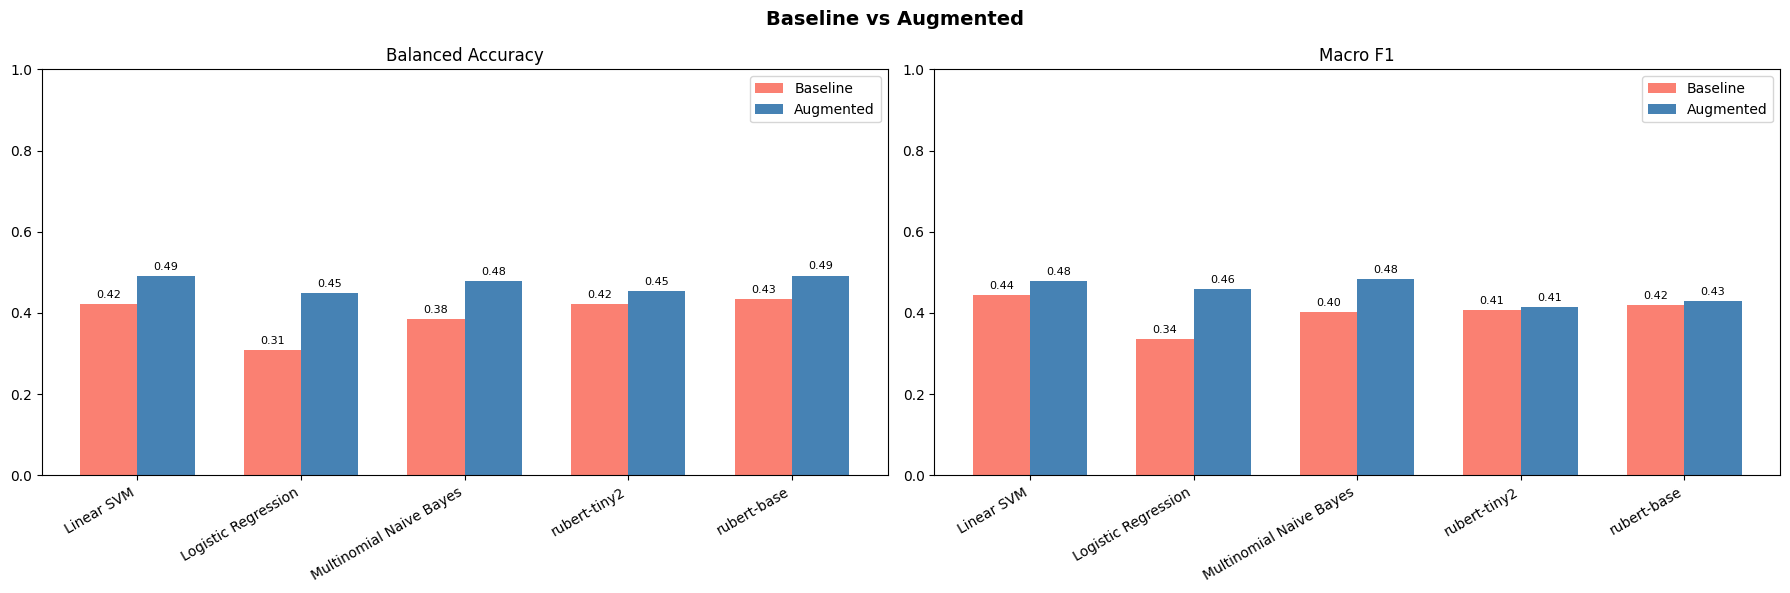


Сохранено: /content/drive/MyDrive/VKR/results/classification_results.csv


In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Названия моделей (без префикса [Baseline]/[Augmented])
model_names = [r["name"].split("] ")[1] for r in baseline_results]

metrics = ["balanced_accuracy", "macro_f1"]
metric_labels = ["Balanced Accuracy", "Macro F1"]

# Таблица
rows = []
print(f"{'Модель':<25} | {'Метрика':<20} | {'Baseline':>10} | {'Augmented':>10} | {'Delta':>10}")
print("-" * 83)
for i, name in enumerate(model_names):
    for m, ml in zip(metrics, metric_labels):
        b = baseline_results[i][m]
        a = augmented_results[i][m]
        delta = a - b
        sign = "+" if delta >= 0 else ""
        print(f"  {name:<23} | {ml:<20} | {b:>10.4f} | {a:>10.4f} | {sign}{delta:>9.4f}")
    print("-" * 83)
    rows.append({
        "stage": "baseline",
        "model": name,
        "balanced_accuracy": round(float(baseline_results[i]["balanced_accuracy"]), 4),
        "macro_f1": round(float(baseline_results[i]["macro_f1"]), 4),
    })
    rows.append({
        "stage": "augmented",
        "model": name,
        "balanced_accuracy": round(float(augmented_results[i]["balanced_accuracy"]), 4),
        "macro_f1": round(float(augmented_results[i]["macro_f1"]), 4),
    })

# График
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(model_names))
width = 0.35

for ax, m, ml in zip(axes, metrics, metric_labels):
    vals_b = [r[m] for r in baseline_results]
    vals_a = [r[m] for r in augmented_results]

    bars_b = ax.bar(x - width/2, vals_b, width, label="Baseline", color="salmon")
    bars_a = ax.bar(x + width/2, vals_a, width, label="Augmented", color="steelblue")

    ax.set_title(ml)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.legend()

    # Подписи значений
    for bar in bars_b:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars_a:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Baseline vs Augmented", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


results_dir = DRIVE_RESULTS
results_dir.mkdir(exist_ok=True)
pd.DataFrame(rows).to_csv(results_dir / "classification_results.csv", index=False)
print(f"\nСохранено: {results_dir / 'classification_results.csv'}")


In [29]:
import pandas as pd
from pathlib import Path

# --- Сводим baseline и augmented результаты в один CSV ---
results_dir = Path(f"{PROJECT_ROOT}/results")
results_dir.mkdir(exist_ok=True)

rows = []
for r in baseline_results:
    rows.append({
        "stage": "baseline",
        "model": r["name"].replace("[Baseline] ", "").replace("[Augmented] ", ""),
        "balanced_accuracy": round(r["balanced_accuracy"], 4),
        "macro_f1": round(r["macro_f1"], 4),
    })
for r in augmented_results:
    rows.append({
        "stage": "augmented",
        "model": r["name"].replace("[Baseline] ", "").replace("[Augmented] ", ""),
        "balanced_accuracy": round(r["balanced_accuracy"], 4),
        "macro_f1": round(r["macro_f1"], 4),
    })

df_results = pd.DataFrame(rows)
csv_path = results_dir / "classification_results.csv"
df_results.to_csv(csv_path, index=False)
print(f"Сохранено: {csv_path}")
print()
print(df_results.to_string(index=False))


Сохранено: /content/VKR/code/results/classification_results.csv

    stage                   model  balanced_accuracy  macro_f1
 baseline              Linear SVM             0.4208    0.4434
 baseline     Logistic Regression             0.3089    0.3350
 baseline Multinomial Naive Bayes             0.3849    0.4026
 baseline            rubert-tiny2             0.4226    0.4069
 baseline             rubert-base             0.4343    0.4198
augmented              Linear SVM             0.4905    0.4785
augmented     Logistic Regression             0.4501    0.4599
augmented Multinomial Naive Bayes             0.4781    0.4826
augmented            rubert-tiny2             0.4549    0.4149
augmented             rubert-base             0.4921    0.4291
